In [1]:
import os
print(os.listdir("/kaggle/input"))


['ucsd-pedestrian-database']


In [2]:
DATASET_PATH = "/kaggle/input/ucsd-pedestrian-database"  # adjust if name differs
print("Exists:", os.path.exists(DATASET_PATH))
print(os.listdir(DATASET_PATH)[:30])


Exists: True
['ucsdpeds']


In [3]:
import glob

imgs = glob.glob(DATASET_PATH + "/**/*.tif", recursive=True) + \
       glob.glob(DATASET_PATH + "/**/*.jpg", recursive=True) + \
       glob.glob(DATASET_PATH + "/**/*.png", recursive=True)

videos = glob.glob(DATASET_PATH + "/**/*.avi", recursive=True) + \
         glob.glob(DATASET_PATH + "/**/*.mp4", recursive=True)

print("Images:", len(imgs))
print("Videos:", len(videos))
print("Sample img:", imgs[0] if imgs else None)
print("Sample video:", videos[0] if videos else None)


Images: 32597
Videos: 0
Sample img: /kaggle/input/ucsd-pedestrian-database/ucsdpeds/vidf/vidf5_33_002.y/vidf5_33_002_f089.png
Sample video: None


In [4]:
import glob, os

# find all images (tif/jpg/png)
imgs = glob.glob(DATASET_PATH + "/**/*.tif", recursive=True) + \
       glob.glob(DATASET_PATH + "/**/*.jpg", recursive=True) + \
       glob.glob(DATASET_PATH + "/**/*.png", recursive=True)

imgs = sorted(imgs)
print("Total frames:", len(imgs))
print("Sample:", imgs[:5])


Total frames: 32597
Sample: ['/kaggle/input/ucsd-pedestrian-database/ucsdpeds/vidf/vidf1_33_000.y/vidf1_33_000_f001.png', '/kaggle/input/ucsd-pedestrian-database/ucsdpeds/vidf/vidf1_33_000.y/vidf1_33_000_f002.png', '/kaggle/input/ucsd-pedestrian-database/ucsdpeds/vidf/vidf1_33_000.y/vidf1_33_000_f003.png', '/kaggle/input/ucsd-pedestrian-database/ucsdpeds/vidf/vidf1_33_000.y/vidf1_33_000_f004.png', '/kaggle/input/ucsd-pedestrian-database/ucsdpeds/vidf/vidf1_33_000.y/vidf1_33_000_f005.png']


In [5]:
frames = imgs[:300]
print("Using frames:", len(frames))


Using frames: 300


In [7]:
!pip -q install ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 17.2 MB/s eta 0:00:00a 0:00:01


In [8]:
import torch
model = torch.hub.load('ultralytics/yolov5', 'yolov5s', pretrained=True)
print("YOLOv5 loaded ✅")


Using cache found in /root/.cache/torch/hub/ultralytics_yolov5_master


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


YOLOv5 🚀 2026-1-16 Python-3.12.12 torch-2.8.0+cu126 CPU

100%|██████████| 14.1M/14.1M [00:00<00:00, 45.9MB/s]

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 


YOLOv5 loaded ✅


In [9]:
import os
import pandas as pd

results = model(frames)
dfs = results.pandas().xyxy

rows = []
for i, df in enumerate(dfs):
    if df is None or len(df) == 0:
        continue
    df = df.copy()
    df["frame_idx"] = i
    df["frame_path"] = frames[i]
    rows.append(df)

det_df = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

# keep only person detections
det_df = det_df[det_df["name"] == "person"].copy()

print("Total person detections:", len(det_df))
det_df.to_csv("/kaggle/working/ucsd_detections.csv", index=False)
print("Saved /kaggle/working/ucsd_detections.csv ✅")

det_df.head()


/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:899: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


Total person detections: 4576
Saved /kaggle/working/ucsd_detections.csv ✅


,xmin,ymin,xmax,ymax,confidence,class,name,frame_idx,frame_path
0,106.219315,72.107361,117.078682,99.005234,0.879814,0,person,0,/kaggle/input/ucsd-pedestrian-database/ucsdped...
1,61.182457,119.600121,70.444626,149.946762,0.822819,0,person,0,/kaggle/input/ucsd-pedestrian-database/ucsdped...
2,179.308563,43.017616,186.889511,62.703030,0.792201,0,person,0,/kaggle/input/ucsd-pedestrian-database/ucsdped...
3,113.510948,113.990372,128.154282,142.382614,0.771463,0,person,0,/kaggle/input/ucsd-pedestrian-database/ucsdped...
4,188.684830,43.825211,196.625183,63.419670,0.770332,0,person,0,/kaggle/input/ucsd-pedestrian-database/ucsdped...


In [10]:
import numpy as np

def iou(boxA, boxB):
    xA = max(boxA[0], boxB[0]); yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2]); yB = min(boxA[3], boxB[3])
    inter = max(0, xB-xA) * max(0, yB-yA)
    if inter <= 0: return 0.0
    areaA = (boxA[2]-boxA[0])*(boxA[3]-boxA[1])
    areaB = (boxB[2]-boxB[0])*(boxB[3]-boxB[1])
    return inter / (areaA + areaB - inter)

det_df = det_df.sort_values(["frame_idx"]).reset_index(drop=True)

next_id = 0
tracks = {}
track_rows = []

for f in sorted(det_df["frame_idx"].unique()):
    df_f = det_df[det_df["frame_idx"] == f]
    assigned = set()

    for _, row in df_f.iterrows():
        box = [row["xmin"], row["ymin"], row["xmax"], row["ymax"]]

        best_tid, best = None, 0.0
        for tid, last_box in tracks.items():
            sc = iou(box, last_box)
            if sc > best:
                best, best_tid = sc, tid

        if best_tid is not None and best > 0.3 and best_tid not in assigned:
            tid = best_tid
        else:
            tid = next_id
            next_id += 1

        tracks[tid] = box
        assigned.add(tid)

        cx = float((box[0] + box[2]) / 2)
        cy = float((box[1] + box[3]) / 2)
        track_rows.append([f, tid, cx, cy, float(row["confidence"]), row["frame_path"]])

import pandas as pd
traj_df = pd.DataFrame(track_rows, columns=["frame", "track_id", "cx", "cy", "conf", "frame_path"])

traj_df.to_csv("/kaggle/working/ucsd_trajectories.csv", index=False)
print("Saved /kaggle/working/ucsd_trajectories.csv ✅")

traj_df.head()


Saved /kaggle/working/ucsd_trajectories.csv ✅


,frame,track_id,cx,cy,conf,frame_path
0,0,0,4.702889,152.598656,0.659682,/kaggle/input/ucsd-pedestrian-database/ucsdped...
1,0,1,98.701920,74.908648,0.610516,/kaggle/input/ucsd-pedestrian-database/ucsdped...
2,0,2,53.691868,100.116276,0.718580,/kaggle/input/ucsd-pedestrian-database/ucsdped...
3,0,3,192.655006,53.622440,0.770332,/kaggle/input/ucsd-pedestrian-database/ucsdped...
4,0,4,183.099037,52.860323,0.792201,/kaggle/input/ucsd-pedestrian-database/ucsdped...


In [11]:
traj_df = traj_df.sort_values(["track_id", "frame"]).copy()

traj_df["vx"] = traj_df.groupby("track_id")["cx"].diff().fillna(0)
traj_df["vy"] = traj_df.groupby("track_id")["cy"].diff().fillna(0)
traj_df["speed"] = np.sqrt(traj_df["vx"]**2 + traj_df["vy"]**2)

frame_score = traj_df.groupby("frame")["speed"].max().reset_index()
p95 = frame_score["speed"].quantile(0.95) + 1e-6
frame_score["anomaly_score"] = (frame_score["speed"] / p95).clip(0, 1)

frame_score.to_csv("/kaggle/working/ucsd_anomaly_scores.csv", index=False)
print("Saved /kaggle/working/ucsd_anomaly_scores.csv ✅")

THRESH = 0.7
alerts = frame_score[frame_score["anomaly_score"] > THRESH].copy()
alerts.to_csv("/kaggle/working/ucsd_alerts.csv", index=False)

print("Alert frames:", len(alerts))
print("Saved /kaggle/working/ucsd_alerts.csv ✅")

frame_score.head()


Saved /kaggle/working/ucsd_anomaly_scores.csv ✅
Alert frames: 67
Saved /kaggle/working/ucsd_alerts.csv ✅


,frame,speed,anomaly_score
0,0,0.000000,0.000000
1,1,2.645729,0.445639
2,2,1.929144,0.324940
3,3,1.706676,0.287468
4,4,3.914114,0.659283


In [16]:
print("frame_score exists?", "frame_score" in globals())



frame_score exists? True


In [17]:
print(type(frame_score))
print(frame_score.shape)
frame_score.head()


<class 'pandas.core.frame.DataFrame'>
(300, 3)


,frame,speed,anomaly_score
0,0,0.000000,0.000000
1,1,2.645729,0.445639
2,2,1.929144,0.324940
3,3,1.706676,0.287468
4,4,3.914114,0.659283


In [20]:
%matplotlib inline


Plotting points: 300


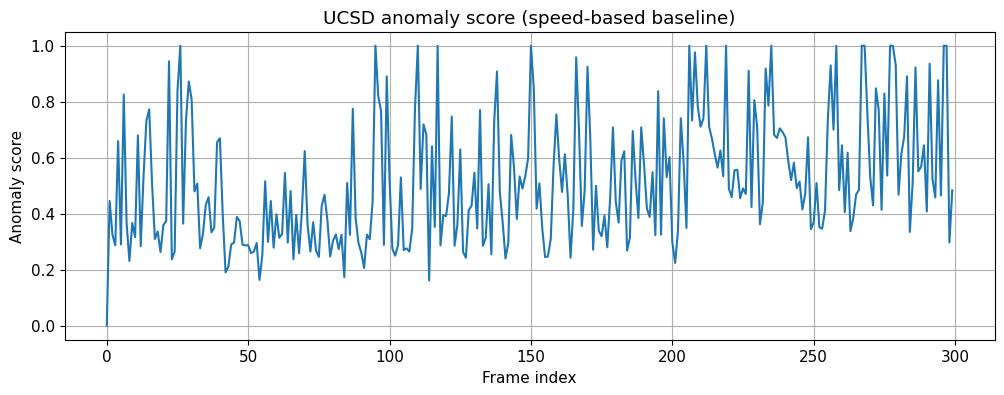

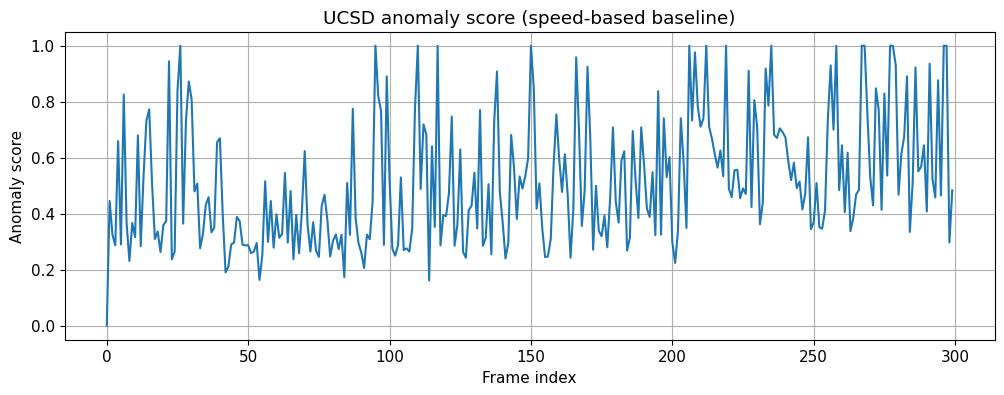

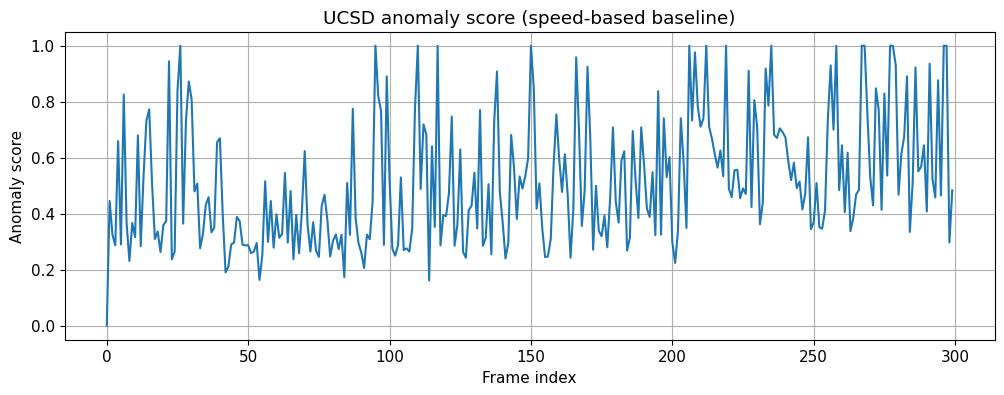

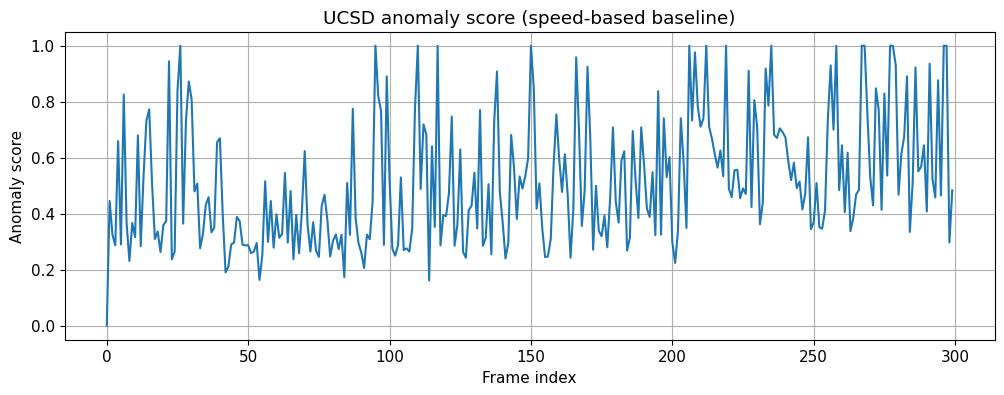

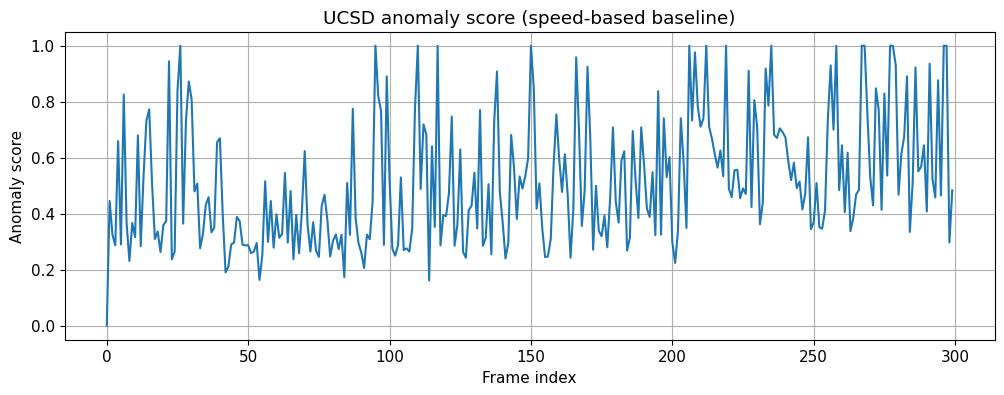

In [21]:
import matplotlib.pyplot as plt

print("Plotting points:", len(frame_score))

fig = plt.figure(figsize=(12,4))
plt.plot(frame_score["frame"].values, frame_score["anomaly_score"].values)
plt.title("UCSD anomaly score (speed-based baseline)")
plt.xlabel("Frame index")
plt.ylabel("Anomaly score")
plt.grid(True)
plt.show()


Saved plot: /kaggle/working/ucsd_anomaly_plot.png


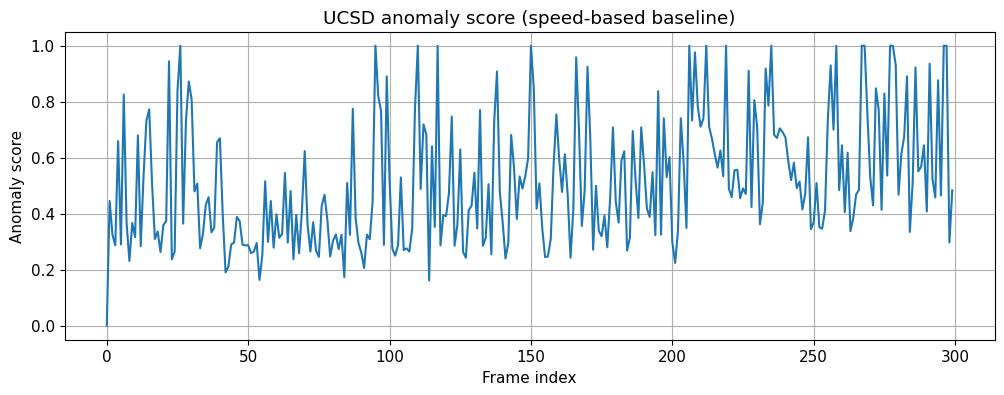

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(frame_score["frame"], frame_score["anomaly_score"])
plt.title("UCSD anomaly score (speed-based baseline)")
plt.xlabel("Frame index")
plt.ylabel("Anomaly score")
plt.grid(True)

out_path = "/kaggle/working/ucsd_anomaly_plot.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
print("Saved plot:", out_path)


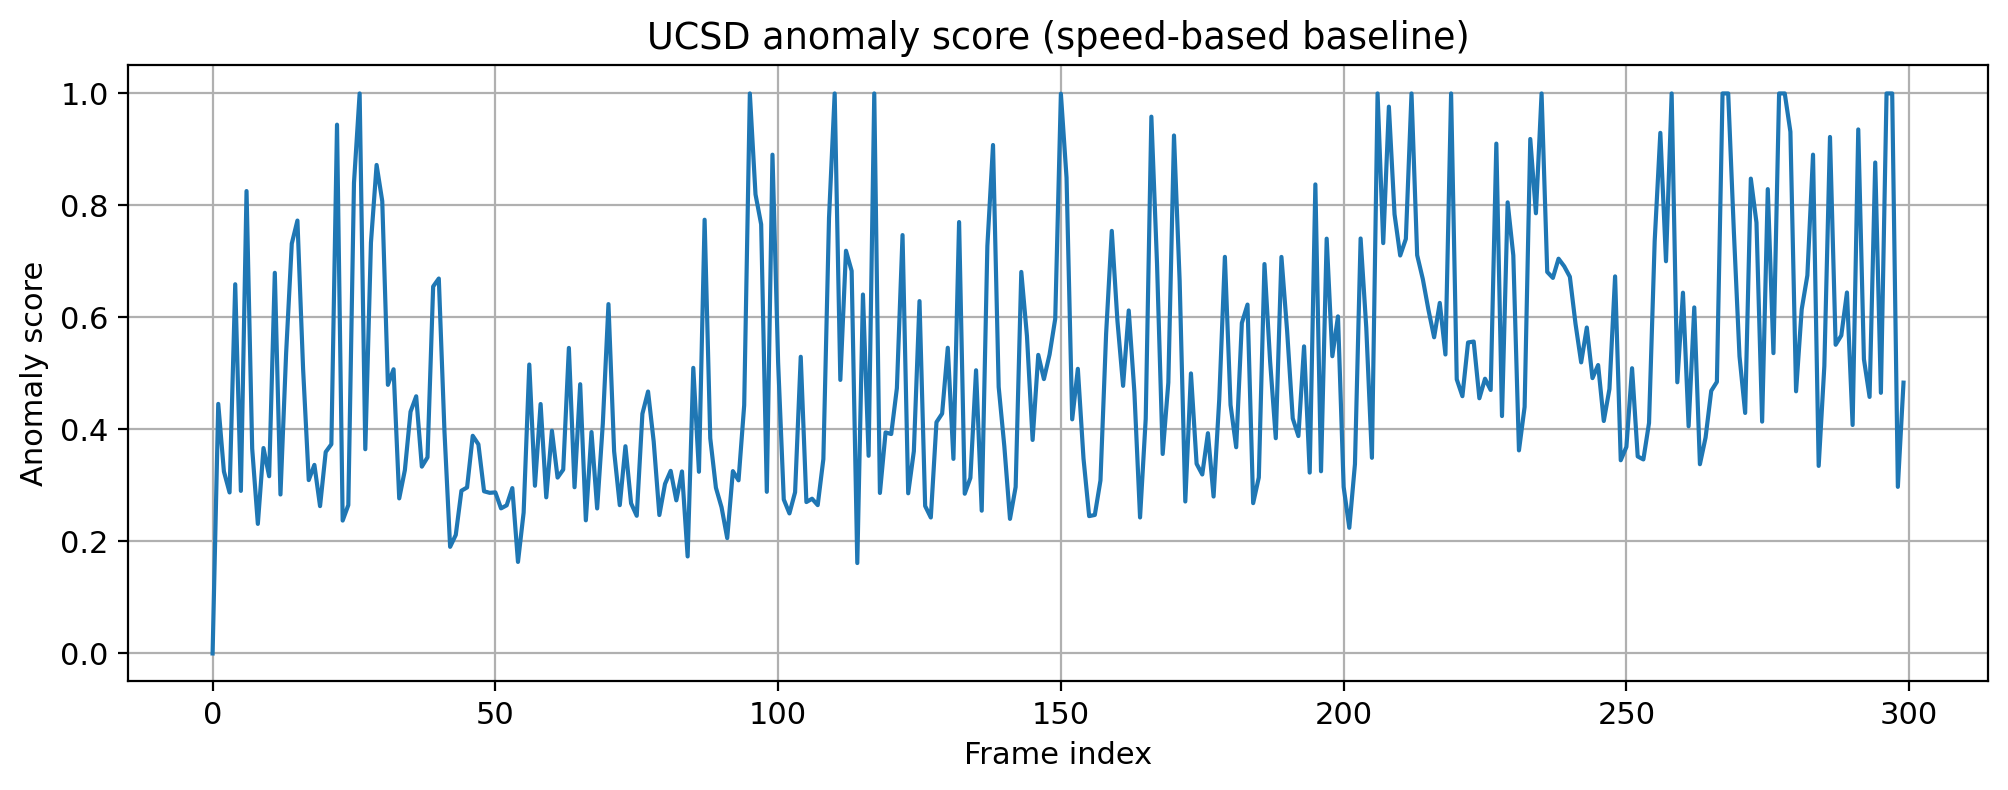

In [23]:
from PIL import Image
Image.open("/kaggle/working/ucsd_anomaly_plot.png")


In [24]:
!zip -r /kaggle/working/ucsd_pipeline_outputs.zip \
    /kaggle/working/ucsd_detections.csv \
    /kaggle/working/ucsd_trajectories.csv \
    /kaggle/working/ucsd_anomaly_scores.csv \
    /kaggle/working/ucsd_alerts.csv \
    /kaggle/working/ucsd_anomaly_plot.png


  adding: kaggle/working/ucsd_detections.csv (deflated 77%)
  adding: kaggle/working/ucsd_trajectories.csv (deflated 79%)
  adding: kaggle/working/ucsd_anomaly_scores.csv (deflated 49%)
  adding: kaggle/working/ucsd_alerts.csv (deflated 49%)
  adding: kaggle/working/ucsd_anomaly_plot.png (deflated 3%)


In [25]:
THRESH = 0.8
alerts = frame_score[frame_score["anomaly_score"] > THRESH].copy()
print("Alert frames:", len(alerts))


Alert frames: 40
